# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 04: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_04_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5859H</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/9/auto+mpg</font>

O dataset Auto MPG, de R. Quinlan, faz parte do ramo automotivo e é usado principalmente para tentar prever o consumo de combustível dos carros em milhas por galão (mpg). A base reúne dados de 398 veículos e relaciona o consumo com características como nome do carro, cilindros, deslocamento do motor, aceleração, ano do modelo, origem, entre outros... De forma geral, ela serve para estudar como essas características influenciam a eficiência de combustível dos automóveis.

## <font color='green'>Preparação</font>

In [3]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo

# Importar o dataset Auto MPG (ID 9)
auto_mpg = fetch_ucirepo(id=9)

# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# Ver as primeiras linhas
display(X.head())

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [13]:
import pandas as pd
print(X.isnull().sum())
print(y.isnull().sum())


df = pd.concat([X, y], axis=1)

linhas_antes = df.shape[0]
df_limpo = df.dropna()


linhas_depois = df_limpo.shape[0] #num de linhas depois da remoçao

# Calculo de linhas removidas
removidas = linhas_antes - linhas_depois

print(f"\nQuantidade de amostras removidas: {removidas}")
print(f"Quantidade de amostras restantes: {linhas_depois}")

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64
mpg    0
dtype: int64

Quantidade de amostras removidas: 6
Quantidade de amostras restantes: 392


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

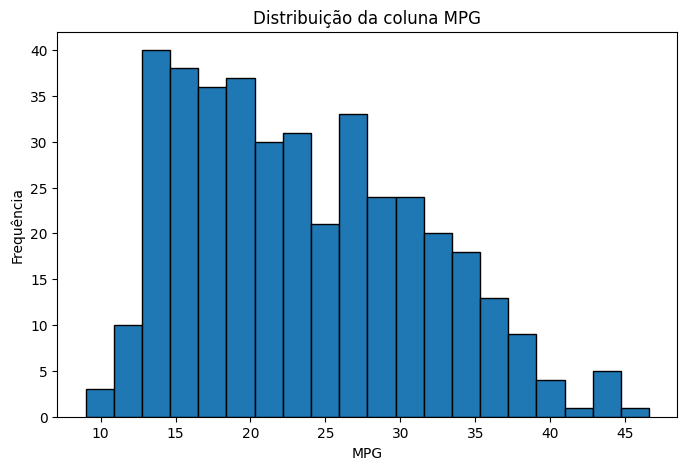

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(y["mpg"], bins=20, edgecolor="black")

plt.title("Distribuição da coluna MPG")
plt.xlabel("MPG")
plt.ylabel("Frequência")

plt.show()

<font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A distribuição do histograma mostra que a maioria dos carros do dataset tem consumo entre aproximadamente 15 e 30 MPG

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

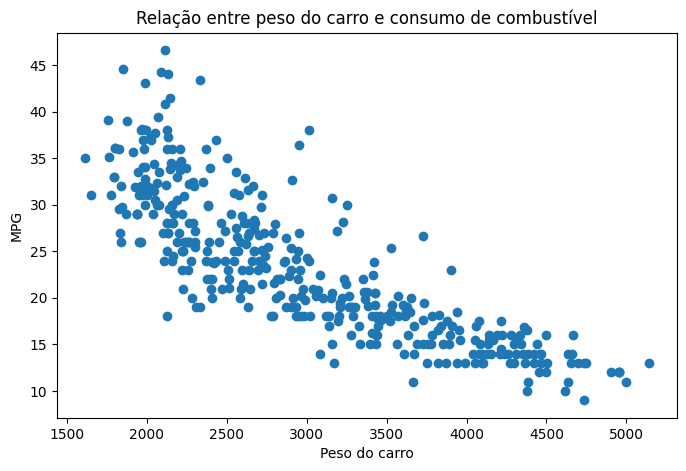

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(df_limpo["weight"], df_limpo["mpg"])

plt.title("Relação entre peso do carro e consumo de combustível")
plt.xlabel("Peso do carro")
plt.ylabel("MPG")

plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

Com o gráfico de dispersão dá para perceber que existe uma relação negativa entre o peso do veículo e o consumo em mpg, ou seja, conforme o carro fica mais pesado, o valor de mpg tende a diminuir, indicando que carros mais pesados costumam consumir mais combustível. Ela parece ter um comportamento não linear, principalmente porque a queda do consumo é mais acentuada em algumas faixas de peso e depois fica mais espalhada. Mesmo assim, podemos ver claramente a tendência geral de que maior peso está associado a menor eficiência de combustível.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

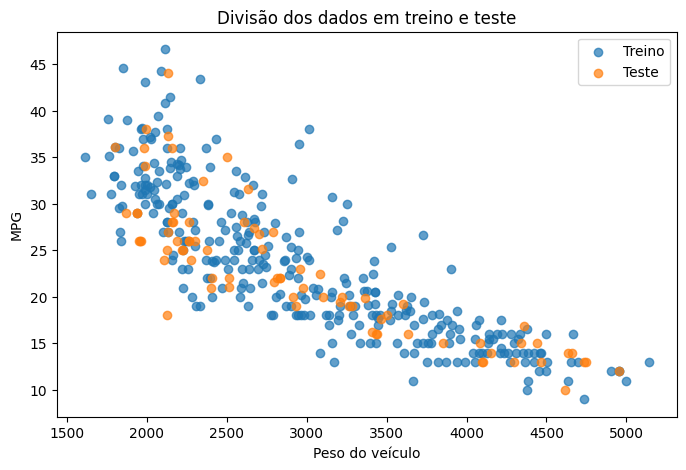

In [18]:
from sklearn.model_selection import train_test_split


X_weight = df_limpo[["weight"]]
y_mpg = df_limpo["mpg"]

# Divisão de dados treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_weight,
    y_mpg,
    test_size=0.2,
    random_state=42
)


plt.figure(figsize=(8, 5))
plt.scatter(X_train["weight"], y_train, label="Treino", alpha=0.7)
plt.scatter(X_test["weight"], y_test, label="Teste", alpha=0.7)
plt.title("Divisão dos dados em treino e teste")
plt.xlabel("Peso do veículo")
plt.ylabel("MPG")
plt.legend()

plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Sim, os conjuntos de treinamento e teste parecem ser representativos do conjunto original. Isso porque, no gráfico, as duas cores aparecem espalhadas de forma parecida ao longo dos valores de weight e mpg.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


modelo_linear = LinearRegression()

modelo_linear.fit(X_train, y_train)

#previsoes
y_train_pred = modelo_linear.predict(X_train)
y_test_pred = modelo_linear.predict(X_test)

print("Métricas - Treinamento")
print("R²:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))

print("\nMétricas - Teste")
print("R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

Métricas - Treinamento
R²: 0.6981745885310532
MAE: 3.2855106233763385
MSE: 19.04510619658238

Métricas - Teste
R²: 0.6533466675646016
MAE: 3.4641211922147592
MSE: 17.693388269545686


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

Comparando o MAE e o MSE do treinamento com os do teste, se os valores ficaram próximos, isso indica que o modelo está se comportando de forma parecida nos dois conjuntos. Nesse caso, ele não parece estar sofrendo de sobreajuste, porque o erro no teste não ficou muito maior que o erro no treino. Também não parece ser um caso forte de subajuste, pois a variável weight tem uma relação clara com mpg e o modelo consegue capturar boa parte dessa tendência. Então, eu diria que o modelo apresenta um ajuste razoável/bom, mas não perfeito, porque a relação entre peso e consumo não é totalmente linear e existem outros fatores que também influenciam o MPG, como potência, cilindros e ano do modelo.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

#modelo de Regressão polinomial de grau 2
modelo_polinomial = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])


modelo_polinomial.fit(X_train, y_train)

#fazer previsoes
y_train_pred_poly = modelo_polinomial.predict(X_train)
y_test_pred_poly = modelo_polinomial.predict(X_test)

print("Métricas - Treinamento")
print("R²:", r2_score(y_train, y_train_pred_poly))
print("MAE:", mean_absolute_error(y_train, y_train_pred_poly))
print("MSE:", mean_squared_error(y_train, y_train_pred_poly))

print("\nMétricas - Teste")
print("R²:", r2_score(y_test, y_test_pred_poly))
print("MAE:", mean_absolute_error(y_test, y_test_pred_poly))
print("MSE:", mean_squared_error(y_test, y_test_pred_poly))

Métricas - Treinamento
R²: 0.72134647941912
MAE: 3.0797805898818913
MSE: 17.582965813534294

Métricas - Teste
R²: 0.6730234425893193
MAE: 3.1383262829057914
MSE: 16.68907419600448


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

O modelo polinomial de grau 2 ficou um pouco melhor que o modelo linear, porque consegue acompanhar melhor a curva entre weight e mpg. Se os erros de treino e teste ficaram próximos, isso mostra que ele não está decorando os dados, então não parece ter overfitting. Também não parece ter underfitting, pois ele representa melhor a relação do que uma reta simples. Portanto, esse modelo parece ter um bom ajuste para os dados.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

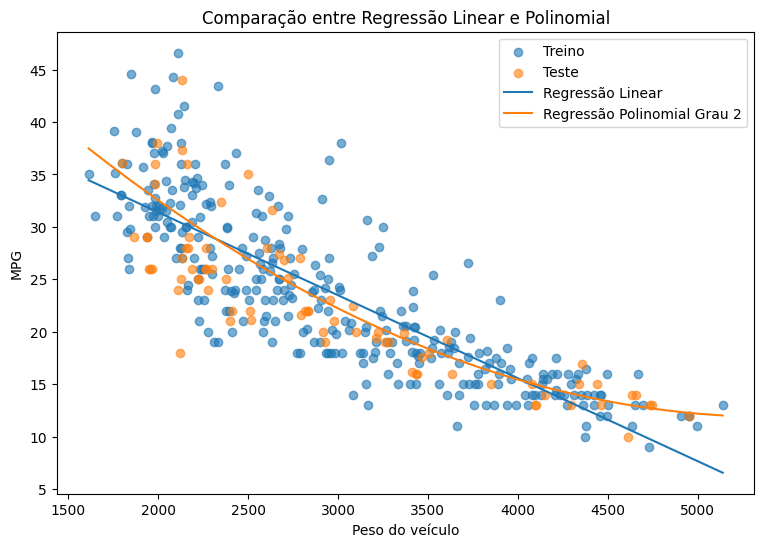

In [21]:
import numpy as np

# Criar uma sequência de pesos para desenhar as linhas/curvas
peso_linha = np.linspace(
    df_limpo["weight"].min(),
    df_limpo["weight"].max(),
    300
)

X_linha = pd.DataFrame({"weight": peso_linha})


mpg_linear = modelo_linear.predict(X_linha)
mpg_polinomial = modelo_polinomial.predict(X_linha)

#Gráfico
plt.figure(figsize=(9, 6))

plt.scatter(X_train["weight"], y_train, label="Treino", alpha=0.6)
plt.scatter(X_test["weight"], y_test, label="Teste", alpha=0.6)

# Linha da regressão
plt.plot(peso_linha, mpg_linear, label="Regressão Linear")
plt.plot(peso_linha, mpg_polinomial, label="Regressão Polinomial Grau 2")

plt.title("Comparação entre Regressão Linear e Polinomial")
plt.xlabel("Peso do veículo")
plt.ylabel("MPG")

plt.legend()
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

Com base no gráfico, o modelo de Regressão Polinomial de grau 2 parece se ajustar melhor aos dados, porque a curva acompanha melhor a tendência dos pontos. A relação entre weight e mpg não parece ser totalmente linear, pois a queda do consumo não forma uma reta perfeita. Conforme o peso do carro aumenta, o mpg diminui, mas essa diminuição acontece de forma mais curva. Por isso, o modelo polinomial representa melhor essa relação do que a regressão linear simples.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, os resultados do gráfico combinam com as métricas. O modelo polinomial parece melhor porque acompanha melhor a curva dos dados, e isso geralmente aparece com erros menores e R de grau 2 maior.

Mesmo assim, o gráfico e as métricas mostram coisas diferentes. O gráfico ajuda a ver visualmente se a linha acompanha bem os pontos. Já as métricas mostram o erro em números. Por isso, o ideal é usar os dois juntos para avaliar melhor o modelo.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [23]:
#com grau alto
modelo_poly_alto = Pipeline([
    ("poly", PolynomialFeatures(degree=15, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

modelo_poly_alto.fit(X_train, y_train)

y_train_pred_alto = modelo_poly_alto.predict(X_train)
y_test_pred_alto = modelo_poly_alto.predict(X_test)


print("Métricas - Treinamento")
print("R²:", r2_score(y_train, y_train_pred_alto))
print("MAE:", mean_absolute_error(y_train, y_train_pred_alto))
print("MSE:", mean_squared_error(y_train, y_train_pred_alto))


print("\nMétricas - Teste")
print("R²:", r2_score(y_test, y_test_pred_alto))
print("MAE:", mean_absolute_error(y_test, y_test_pred_alto))
print("MSE:", mean_squared_error(y_test, y_test_pred_alto))

Métricas - Treinamento
R²: 0.7327701968224645
MAE: 3.0388831232633624
MSE: 16.86213216984745

Métricas - Teste
R²: 0.6607135973124754
MAE: 3.158319963228482
MSE: 17.3173758785271


Com um grau muito alto, como 15, o modelo tende a se ajustar muito bem aos dados de treinamento, então o erro no treino pode ficar menor. Porém, no conjunto de teste, o desempenho geralmente piora, com MAE e MSE maiores e possivelmente um R² menor. Isso acontece por causa do overfitting, ou seja, o modelo começa a “decorar” os dados de treino em vez de aprender a tendência geral. Por isso, ele funciona bem nos dados que já viu, mas erra mais quando recebe dados novos.

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [24]:
from sklearn.linear_model import SGDRegressor

# Separar novamente X e y usando o dataset limpo
X_sgd = df_limpo.drop(columns=["mpg"])
y_sgd = df_limpo["mpg"]

# Dividir em treino e teste
X_train_sgd, X_test_sgd, y_train_sgd, y_test_sgd = train_test_split(
    X_sgd,
    y_sgd,
    test_size=0.2,
    random_state=42
)

# Criar e treinar o modelo SGD diretamente nos dados originais
modelo_sgd = SGDRegressor(random_state=42)

modelo_sgd.fit(X_train_sgd, y_train_sgd)

#previsões
y_train_pred_sgd = modelo_sgd.predict(X_train_sgd)
y_test_pred_sgd = modelo_sgd.predict(X_test_sgd)


print("Métricas - Treinamento")
print("R²:", r2_score(y_train_sgd, y_train_pred_sgd))
print("MAE:", mean_absolute_error(y_train_sgd, y_train_pred_sgd))
print("MSE:", mean_squared_error(y_train_sgd, y_train_pred_sgd))

print("\nMétricas - Teste")
print("R²:", r2_score(y_test_sgd, y_test_pred_sgd))
print("MAE:", mean_absolute_error(y_test_sgd, y_test_pred_sgd))
print("MSE:", mean_squared_error(y_test_sgd, y_test_pred_sgd))

Métricas - Treinamento
R²: -1.7098221473807485e+29
MAE: 3161137688338287.5
MSE: 1.0788933978637248e+31

Métricas - Teste
R²: -2.0760980030561058e+29
MAE: 3117757696832941.0
MSE: 1.0596525293910353e+31


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [25]:
# Criar o modelo com padronização + SGDRegressor
modelo_sgd_scaler = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDRegressor(random_state=42))
])

# Treinar o modelo
modelo_sgd_scaler.fit(X_train_sgd, y_train_sgd)

# Fazer previsões
y_train_pred_sgd_scaler = modelo_sgd_scaler.predict(X_train_sgd)
y_test_pred_sgd_scaler = modelo_sgd_scaler.predict(X_test_sgd)

print("Métricas - Treinamento")
print("R²:", r2_score(y_train_sgd, y_train_pred_sgd_scaler))
print("MAE:", mean_absolute_error(y_train_sgd, y_train_pred_sgd_scaler))
print("MSE:", mean_squared_error(y_train_sgd, y_train_pred_sgd_scaler))

print("\nMétricas - Teste")
print("R²:", r2_score(y_test_sgd, y_test_pred_sgd_scaler))
print("MAE:", mean_absolute_error(y_test_sgd, y_test_pred_sgd_scaler))
print("MSE:", mean_squared_error(y_test_sgd, y_test_pred_sgd_scaler))

Métricas - Treinamento
R²: 0.8230022968450478
MAE: 2.5337452926128474
MSE: 11.168509757781107

Métricas - Teste
R²: 0.7771164878844177
MAE: 2.48594401094042
MSE: 11.376104452928928


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

Com os dados originais, o SGDRegressor teve pior desempenho, porque as variáveis estavam em escalas muito diferentes. Por exemplo, weight possui valores bem maiores que origin ou acceleration, então ele influencia mais o cálculo do gradiente.
Depois do StandardScaler, as variáveis ficam em escalas parecidas. Isso ajuda o gradiente descendente a atualizar os pesos de forma mais equilibrada, melhorando a convergência e reduzindo os erros.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [27]:
from sklearn.linear_model import Lasso

#dataset limpo
X_lasso = df_limpo.drop(columns=["mpg"])
y_lasso = df_limpo["mpg"]

# Criar Pipeline com normalização + LASSO
modelo_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1.0))
])

modelo_lasso.fit(X_lasso, y_lasso)

# Exibir coeficientes finais
coeficientes = pd.DataFrame({
    "Variável": X_lasso.columns,
    "Coeficiente": modelo_lasso.named_steps["lasso"].coef_
})

display(coeficientes)

,Variável,Coeficiente
0,displacement,-0.000000
1,cylinders,-0.000000
2,horsepower,-0.167700
3,weight,-4.545532
4,acceleration,0.000000
5,model_year,1.994436
6,origin,0.308290


### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [28]:
alphas = [0.1, 1.0, 5.0]

for alpha in alphas:
    modelo_lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, max_iter=10000))
    ])

    modelo_lasso.fit(X_lasso, y_lasso)

    coeficientes = modelo_lasso.named_steps["lasso"].coef_

    variaveis_sobreviventes = X_lasso.columns[coeficientes != 0]

    print(f"Alpha = {alpha}")
    print("Variáveis que sobreviveram:")
    print(list(variaveis_sobreviventes))
    print()

Alpha = 0.1
Variáveis que sobreviveram:
['horsepower', 'weight', 'acceleration', 'model_year', 'origin']

Alpha = 1.0
Variáveis que sobreviveram:
['horsepower', 'weight', 'model_year', 'origin']

Alpha = 5.0
Variáveis que sobreviveram:
['weight']



A medida que o valor de alpha aumenta, a regularização fica mais forte. Com isso, o LASSO começa a zerar mais coeficientes e menos variáveis sobrevivem no modelo. Portanto, quanto maior o alpha, mais simples o modelo fica, porque ele passa a usar menos atributos para fazer a previsão.